In [2]:
# Complete RUL Prediction Pipeline for NASA Battery Data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ============================================
# CONFIGURATION
# ============================================

# Set paths (adjust if needed)
NOTEBOOK_DIR = Path.cwd()
MODEL_DIR = NOTEBOOK_DIR.parent
DATA_PROCESSED = MODEL_DIR / "data" / "processed"

# Input file
input_csv = DATA_PROCESSED / "nasa_training_data.csv"

print("=" * 60)
print("RUL Prediction Pipeline")
print("=" * 60)
print(f"Input file: {input_csv}")
print(f"File exists: {input_csv.exists()}")

RUL Prediction Pipeline
Input file: /media/lenovo/New Volume1/Programming/App_Dev/Battery_Manager_Backend_and_Model/model/data/processed/nasa_training_data.csv
File exists: True


In [4]:
# ============================================
# SECTION 1: Load Data
# ============================================

print("\n" + "=" * 60)
print("SECTION 1: Loading Data")
print("=" * 60)

# Target batteries (classic 4)
TARGET_BATTERIES = ["B0005", "B0006", "B0007", "B0018"]

df = pd.read_csv(input_csv)
df = df[df['battery_id'].isin(TARGET_BATTERIES)].copy()

print(f"Batteries loaded: {df['battery_id'].unique()}")
print(f"Total cycles: {len(df):,}")
print(f"Health range: {df['soh_percent'].min():.1f}% - {df['soh_percent'].max():.1f}%")

df.head(10)


SECTION 1: Loading Data
Batteries loaded: ['B0005' 'B0006' 'B0007' 'B0018']
Total cycles: 636
Health range: 57.7% - 101.8%


,battery_id,cycle_number,capacity_ah,avg_temperature_c,max_temperature_c,min_temperature_c,duration_seconds,start_voltage_v,end_voltage_v,soh_percent
0,B0005,2,1.856487,32.572328,38.982181,24.325993,3690.234,4.191492,3.277170,92.824371
1,B0005,4,1.846327,32.725235,39.033398,24.685948,3672.344,4.189773,3.300245,92.316362
2,B0005,6,1.835349,32.642862,38.818797,24.734266,3651.641,4.188187,3.327451,91.767460
3,B0005,8,1.835263,32.514876,38.762305,24.652244,3631.563,4.188461,3.314182,91.763126
4,B0005,10,1.834646,32.382349,38.665393,24.518700,3629.172,4.188299,3.305497,91.732275
5,B0005,12,1.835662,32.434182,38.751695,24.514427,3652.281,4.188816,3.302329,91.783083
6,B0005,14,1.835146,32.480416,38.820701,24.575581,3650.828,4.188392,3.293741,91.757307
7,B0005,16,1.825757,32.410462,38.517130,24.711324,3572.453,4.188928,3.316231,91.287840
8,B0005,18,1.824774,32.346141,38.526268,24.628487,3550.594,4.189029,3.297411,91.238693
9,B0005,20,1.824613,32.276798,38.526981,24.561560,3551.250,4.189223,3.288404,91.230663


In [5]:
# ============================================
# SECTION 2: Calculate RUL (to 70% health)
# ============================================

print("\n" + "=" * 60)
print("SECTION 2: Calculating Remaining Useful Life (RUL)")
print("=" * 60)

TARGET_HEALTH = 70  # NASA's EOL definition
print(f"Target health: {TARGET_HEALTH}%")

def calculate_rul(battery_df):
    """Calculate RUL for each cycle in a battery"""
    battery_df = battery_df.sort_values('cycle_number')
    
    # Find first cycle at or below target health
    below_target = battery_df[battery_df['soh_percent'] <= TARGET_HEALTH]
    
    if len(below_target) > 0:
        eol_cycle = below_target['cycle_number'].iloc[0]
        battery_df['rul_cycles'] = battery_df['cycle_number'].apply(
            lambda x: max(0, eol_cycle - x)
        )
        battery_df['reached_target'] = True
        print(f"  {battery_df['battery_id'].iloc[0]}: EOL at cycle {eol_cycle}")
    else:
        # Censored - didn't reach target
        max_cycle = battery_df['cycle_number'].max()
        battery_df['rul_cycles'] = battery_df['cycle_number'].apply(
            lambda x: max(0, max_cycle - x)
        )
        battery_df['reached_target'] = False
        print(f"  {battery_df['battery_id'].iloc[0]}: Censored (min health: {battery_df['soh_percent'].min():.1f}%)")
    
    return battery_df

# Apply to each battery
rul_dfs = []
for battery_id in TARGET_BATTERIES:
    battery_df = df[df['battery_id'] == battery_id].copy()
    battery_df = calculate_rul(battery_df)
    rul_dfs.append(battery_df)

rul_df = pd.concat(rul_dfs, ignore_index=True)

print(f"\nRUL Statistics:")
print(f"  Min RUL: {rul_df['rul_cycles'].min()}")
print(f"  Max RUL: {rul_df['rul_cycles'].max()}")
print(f"  Mean RUL: {rul_df['rul_cycles'].mean():.1f}")


SECTION 2: Calculating Remaining Useful Life (RUL)
Target health: 70%
  B0005: EOL at cycle 449
  B0006: EOL at cycle 387
  B0007: Censored (min health: 70.0%)
  B0018: EOL at cycle 237

RUL Statistics:
  Min RUL: 0
  Max RUL: 612
  Mean RUL: 183.9


In [6]:
# ============================================
# SECTION 3: Feature Engineering
# ============================================

print("\n" + "=" * 60)
print("SECTION 3: Feature Engineering")
print("=" * 60)

def create_features(df):
    """Create features for RUL prediction"""
    df = df.copy()
    df = df.sort_values(['battery_id', 'cycle_number'])
    
    # 1. Degradation rate (change in SOH per cycle)
    df['soh_change'] = df.groupby('battery_id')['soh_percent'].diff()
    df['degradation_rate'] = -df['soh_change']  # Positive = degradation
    
    # 2. Rolling statistics (last 5 cycles)
    df['soh_ma5'] = df.groupby('battery_id')['soh_percent'].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )
    df['temp_ma5'] = df.groupby('battery_id')['avg_temperature_c'].transform(
        lambda x: x.rolling(5, min_periods=1).mean()
    )
    
    # 3. Cumulative features
    df['cycles_so_far'] = df['cycle_number']
    df['soh_loss_so_far'] = 100 - df['soh_percent']
    
    # 4. Time-based features
    df['log_cycle'] = np.log1p(df['cycle_number'])
    df['sqrt_cycle'] = np.sqrt(df['cycle_number'])
    
    # 5. Temperature features
    df['temp_range'] = df['max_temperature_c'] - df['min_temperature_c']
    
    return df

feature_df = create_features(rul_df)

print(f"Original columns: {len(rul_df.columns)}")
print(f"After feature engineering: {len(feature_df.columns)}")
print(f"New features: soh_change, degradation_rate, soh_ma5, temp_ma5, log_cycle, sqrt_cycle, temp_range")

feature_df.head(10)


SECTION 3: Feature Engineering
Original columns: 12
After feature engineering: 21
New features: soh_change, degradation_rate, soh_ma5, temp_ma5, log_cycle, sqrt_cycle, temp_range


,battery_id,cycle_number,capacity_ah,avg_temperature_c,max_temperature_c,min_temperature_c,duration_seconds,start_voltage_v,end_voltage_v,soh_percent,...,reached_target,soh_change,degradation_rate,soh_ma5,temp_ma5,cycles_so_far,soh_loss_so_far,log_cycle,sqrt_cycle,temp_range
0,B0005,2,1.856487,32.572328,38.982181,24.325993,3690.234,4.191492,3.277170,92.824371,...,True,NaN,NaN,92.824371,32.572328,2,7.175629,1.098612,1.414214,14.656188
1,B0005,4,1.846327,32.725235,39.033398,24.685948,3672.344,4.189773,3.300245,92.316362,...,True,-0.508009,0.508009,92.570367,32.648782,4,7.683638,1.609438,2.000000,14.347450
2,B0005,6,1.835349,32.642862,38.818797,24.734266,3651.641,4.188187,3.327451,91.767460,...,True,-0.548903,0.548903,92.302731,32.646808,6,8.232540,1.945910,2.449490,14.084531
3,B0005,8,1.835263,32.514876,38.762305,24.652244,3631.563,4.188461,3.314182,91.763126,...,True,-0.004333,0.004333,92.167830,32.613825,8,8.236874,2.197225,2.828427,14.110061
4,B0005,10,1.834646,32.382349,38.665393,24.518700,3629.172,4.188299,3.305497,91.732275,...,True,-0.030851,0.030851,92.080719,32.567530,10,8.267725,2.397895,3.162278,14.146692
5,B0005,12,1.835662,32.434182,38.751695,24.514427,3652.281,4.188816,3.302329,91.783083,...,True,0.050808,-0.050808,91.872461,32.539901,12,8.216917,2.564949,3.464102,14.237268
6,B0005,14,1.835146,32.480416,38.820701,24.575581,3650.828,4.188392,3.293741,91.757307,...,True,-0.025776,0.025776,91.760650,32.490937,14,8.242693,2.708050,3.741657,14.245120
7,B0005,16,1.825757,32.410462,38.517130,24.711324,3572.453,4.188928,3.316231,91.287840,...,True,-0.469468,0.469468,91.664726,32.444457,16,8.712160,2.833213,4.000000,13.805806
8,B0005,18,1.824774,32.346141,38.526268,24.628487,3550.594,4.189029,3.297411,91.238693,...,True,-0.049147,0.049147,91.559840,32.410710,18,8.761307,2.944439,4.242641,13.897781
9,B0005,20,1.824613,32.276798,38.526981,24.561560,3551.250,4.189223,3.288404,91.230663,...,True,-0.008029,0.008029,91.459517,32.389600,20,8.769337,3.044522,4.472136,13.965421


In [7]:
# ============================================
# SECTION 4: Filter to Early Cycles (80% of life)
# ============================================

print("\n" + "=" * 60)
print("SECTION 4: Filter to Early Cycles")
print("=" * 60)

EARLY_RATIO = 0.8
print(f"Keeping first {EARLY_RATIO * 100}% of battery life")

def filter_early_cycles(df, early_ratio=EARLY_RATIO):
    """Keep only early cycles for training"""
    filtered_dfs = []
    
    for battery_id in df['battery_id'].unique():
        battery_df = df[df['battery_id'] == battery_id].copy()
        max_cycle = battery_df['cycle_number'].max()
        early_max = int(max_cycle * early_ratio)
        
        early_df = battery_df[battery_df['cycle_number'] <= early_max]
        filtered_dfs.append(early_df)
        print(f"  {battery_id}: {len(battery_df)} cycles → {len(early_df)} cycles (cutoff at cycle {early_max})")
    
    return pd.concat(filtered_dfs, ignore_index=True)

# Keep cycles where RUL > 0
training_df = feature_df[feature_df['rul_cycles'] > 0].copy()
print(f"\nCycles with RUL > 0: {len(training_df)}")

# Filter to early cycles
training_df_early = filter_early_cycles(training_df, early_ratio=EARLY_RATIO)
print(f"\nEarly cycles (first {EARLY_RATIO * 100}% of life): {len(training_df_early)}")


SECTION 4: Filter to Early Cycles
Keeping first 80.0% of battery life

Cycles with RUL > 0: 495
  B0005: 124 cycles → 101 cycles (cutoff at cycle 356)
  B0006: 108 cycles → 88 cycles (cutoff at cycle 306)
  B0007: 167 cycles → 136 cycles (cutoff at cycle 489)
  B0018: 96 cycles → 76 cycles (cutoff at cycle 188)

Early cycles (first 80.0% of life): 401


In [8]:
# ============================================
# SECTION 5: Select Features for ML
# ============================================

print("\n" + "=" * 60)
print("SECTION 5: Selecting Features")
print("=" * 60)

# Features to use for prediction
feature_columns = [
    'cycle_number',
    'soh_percent',
    'avg_temperature_c',
    'max_temperature_c',
    'duration_seconds',
    'degradation_rate',
    'soh_ma5',
    'temp_ma5',
    'cycles_so_far',
    'soh_loss_so_far',
    'log_cycle',
    'sqrt_cycle',
    'temp_range'
]

# Target
target_column = 'rul_cycles'

# Check which features exist
available_features = [f for f in feature_columns if f in training_df_early.columns]
print(f"Available features: {len(available_features)}")
print(f"Features: {available_features}")


SECTION 5: Selecting Features
Available features: 13
Features: ['cycle_number', 'soh_percent', 'avg_temperature_c', 'max_temperature_c', 'duration_seconds', 'degradation_rate', 'soh_ma5', 'temp_ma5', 'cycles_so_far', 'soh_loss_so_far', 'log_cycle', 'sqrt_cycle', 'temp_range']


In [9]:
# ============================================
# SECTION 6: Simple Train/Test Split (80/20 per battery)
# ============================================

print("\n" + "=" * 60)
print("SECTION 6: Simple Train/Test Split (80/20 per battery)")
print("=" * 60)

from sklearn.model_selection import train_test_split

# Split each battery individually
train_dfs = []
test_dfs = []

for battery_id in training_df_early['battery_id'].unique():
    battery_data = training_df_early[training_df_early['battery_id'] == battery_id]
    
    # Split this battery: 80% train, 20% test
    battery_train, battery_test = train_test_split(
        battery_data, 
        test_size=0.2, 
        random_state=42,
        shuffle=True  # Randomly select cycles from this battery
    )
    
    train_dfs.append(battery_train)
    test_dfs.append(battery_test)
    
    print(f"\n{battery_id}:")
    print(f"  Total cycles: {len(battery_data)}")
    print(f"  Train: {len(battery_train)} cycles ({len(battery_train)/len(battery_data)*100:.0f}%)")
    print(f"  Test: {len(battery_test)} cycles ({len(battery_test)/len(battery_data)*100:.0f}%)")

# Combine all batteries
train_df = pd.concat(train_dfs, ignore_index=True)
test_df = pd.concat(test_dfs, ignore_index=True)

print(f"\n" + "=" * 60)
print(f"TOTAL:")
print(f"  Train cycles: {len(train_df)}")
print(f"  Test cycles: {len(test_df)}")
print(f"  Train/Test ratio: {len(train_df)/len(test_df):.1f}/1")

# Show cycle range for each battery in train and test
print("\n" + "=" * 60)
print("CYCLE DISTRIBUTION BY BATTERY:")
print("=" * 60)

for battery_id in training_df_early['battery_id'].unique():
    train_bat = train_df[train_df['battery_id'] == battery_id]
    test_bat = test_df[test_df['battery_id'] == battery_id]
    
    print(f"\n{battery_id}:")
    print(f"  Train cycles: {train_bat['cycle_number'].min()}-{train_bat['cycle_number'].max()}")
    print(f"  Test cycles: {test_bat['cycle_number'].min()}-{test_bat['cycle_number'].max()}")


SECTION 6: Simple Train/Test Split (80/20 per battery)

B0005:
  Total cycles: 101
  Train: 80 cycles (79%)
  Test: 21 cycles (21%)

B0006:
  Total cycles: 88
  Train: 70 cycles (80%)
  Test: 18 cycles (20%)

B0007:
  Total cycles: 136
  Train: 108 cycles (79%)
  Test: 28 cycles (21%)

B0018:
  Total cycles: 76
  Train: 60 cycles (79%)
  Test: 16 cycles (21%)

TOTAL:
  Train cycles: 318
  Test cycles: 83
  Train/Test ratio: 3.8/1

CYCLE DISTRIBUTION BY BATTERY:

B0005:
  Train cycles: 4-356
  Test cycles: 2-344

B0006:
  Train cycles: 4-306
  Test cycles: 2-298

B0007:
  Train cycles: 2-489
  Test cycles: 10-481

B0018:
  Train cycles: 7-188
  Test cycles: 3-177


In [10]:
# ============================================
# SECTION 7: Train and Compare Models (Simple Train/Test)
# ============================================

print("\n" + "=" * 60)
print("SECTION 7: Training and Comparing Models")
print("=" * 60)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
from lightgbm import LGBMRegressor
import time

# Prepare data (using train_df and test_df from Section 6)
# First, remove NaN values
train_df_clean = train_df.dropna(subset=available_features)
test_df_clean = test_df.dropna(subset=available_features)

X_train = train_df_clean[available_features]
y_train = train_df_clean['rul_cycles']
X_test = test_df_clean[available_features]
y_test = test_df_clean['rul_cycles']

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"NaN removed: Train={len(train_df)-len(X_train)}, Test={len(test_df)-len(X_test)}")

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    'LightGBM': LGBMRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbose=-1)
}

# Train and evaluate
results = []
best_model = None
best_test_mae = float('inf')

for name, model in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()
    
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Metrics
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    results.append({
        'Model': name,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Test R²': test_r2,
        'Train Time (s)': train_time
    })
    
    print(f"  Test MAE: {test_mae:.1f} cycles, R²: {test_r2:.3f}")
    
    if test_mae < best_test_mae:
        best_test_mae = test_mae
        best_model = model
        best_model_name = name

# Display results
results_df = pd.DataFrame(results)
print("\n" + "=" * 60)
print("MODEL COMPARISON RESULTS")
print("=" * 60)
print(results_df.to_string(index=False))

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Test MAE: {best_test_mae:.1f} cycles")


SECTION 7: Training and Comparing Models
Training samples: 317
Test samples: 80
NaN removed: Train=1, Test=3

Training Linear Regression...
  Test MAE: 34.2 cycles, R²: 0.920

Training Random Forest...
  Test MAE: 10.0 cycles, R²: 0.987

Training XGBoost...
  Test MAE: 9.7 cycles, R²: 0.986

Training LightGBM...
  Test MAE: 13.0 cycles, R²: 0.985

MODEL COMPARISON RESULTS
            Model  Train MAE  Test MAE  Test R²  Train Time (s)
Linear Regression  31.693357 34.225595 0.920401        0.006096
    Random Forest   4.728328 10.009375 0.987478        0.094776
          XGBoost   1.167247  9.679836 0.986463        0.317696
         LightGBM   6.624592 13.027899 0.984772        0.056440

🏆 BEST MODEL: XGBoost
   Test MAE: 9.7 cycles



SECTION 8: Feature Importance

Top 10 Features:
          feature  importance
          soh_ma5    0.408918
       temp_range    0.209074
  soh_loss_so_far    0.161056
      soh_percent    0.104261
max_temperature_c    0.060476
         temp_ma5    0.024166
     cycle_number    0.014840
 duration_seconds    0.013225
avg_temperature_c    0.002976
 degradation_rate    0.001009


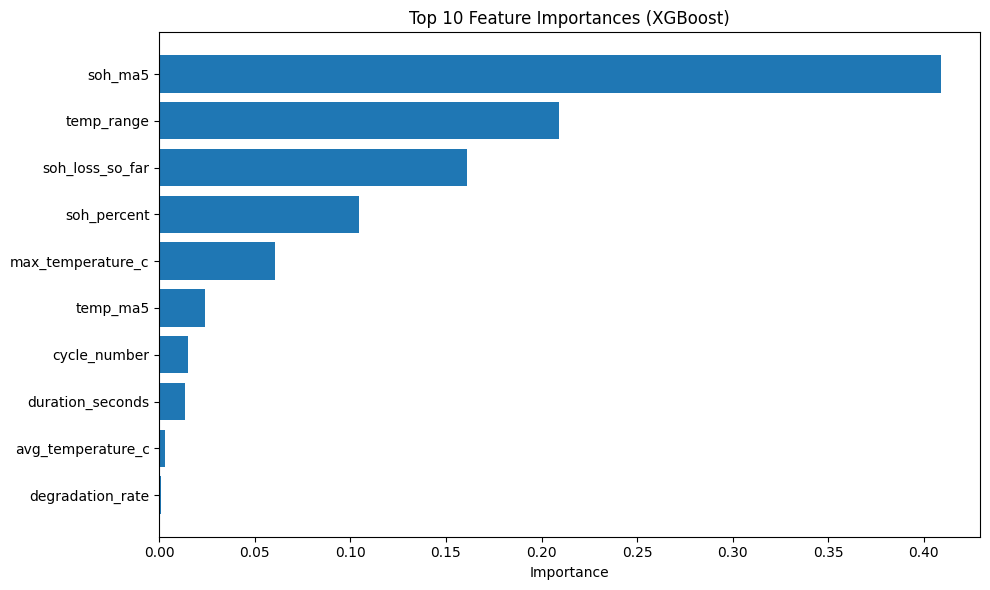

In [11]:
# ============================================
# SECTION 8: Feature Importance
# ============================================

print("\n" + "=" * 60)
print("SECTION 8: Feature Importance")
print("=" * 60)

if best_model_name in ['Random Forest', 'XGBoost', 'LightGBM']:
    importances = best_model.feature_importances_
    importance_df = pd.DataFrame({
        'feature': available_features,
        'importance': importances
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Features:")
    print(importance_df.head(10).to_string(index=False))
    
    # Plot
    plt.figure(figsize=(10, 6))
    top_features = importance_df.head(10)
    plt.barh(top_features['feature'], top_features['importance'])
    plt.xlabel('Importance')
    plt.title(f'Top 10 Feature Importances ({best_model_name})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    # Linear Regression - show coefficients
    coef_df = pd.DataFrame({
        'feature': available_features,
        'coefficient': best_model.coef_
    }).sort_values('coefficient', key=abs, ascending=False)
    print("\nTop 10 Coefficients (absolute value):")
    print(coef_df.head(10).to_string(index=False))


SECTION 9: Visualizing Predictions


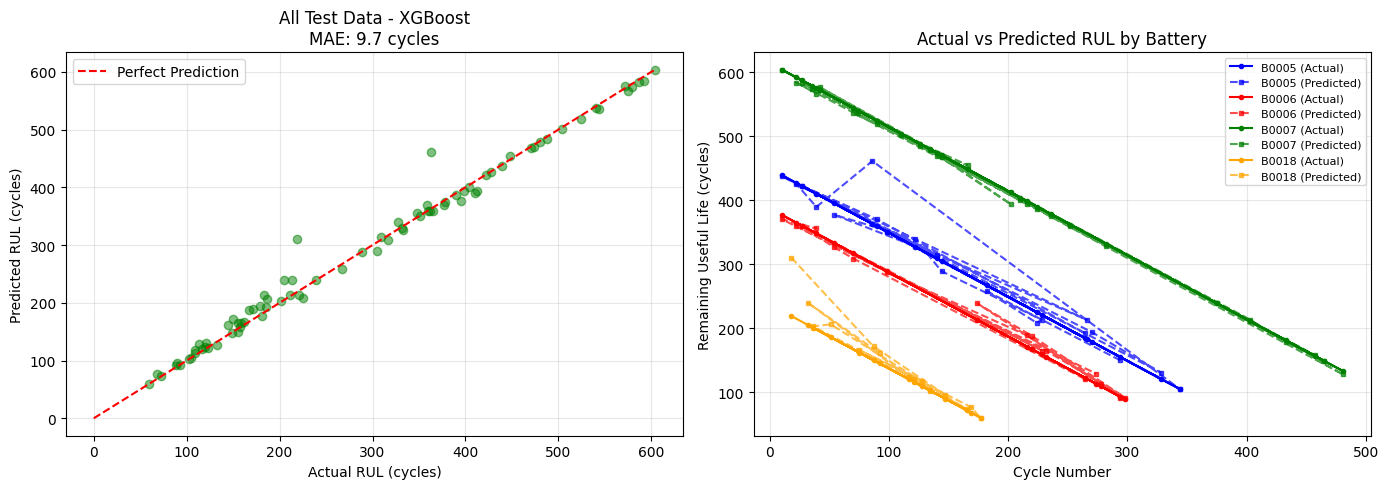

In [12]:
# ============================================
# SECTION 9: Visualize Predictions
# ============================================

print("\n" + "=" * 60)
print("SECTION 9: Visualizing Predictions")
print("=" * 60)

# Predict on test set
y_test_pred = best_model.predict(X_test)

# Create a dataframe with predictions
test_with_pred = test_df_clean.copy()
test_with_pred['predicted_rul'] = y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot (all test data)
axes[0].scatter(y_test, y_test_pred, alpha=0.5, color='green')
axes[0].plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual RUL (cycles)')
axes[0].set_ylabel('Predicted RUL (cycles)')
axes[0].set_title(f'All Test Data - {best_model_name}\nMAE: {best_test_mae:.1f} cycles')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RUL over time (show each battery with different colors)
colors = ['blue', 'red', 'green', 'orange']
for idx, battery_id in enumerate(test_with_pred['battery_id'].unique()):
    battery_data = test_with_pred[test_with_pred['battery_id'] == battery_id]
    axes[1].plot(battery_data['cycle_number'], battery_data['rul_cycles'], 
                 'o-', color=colors[idx % len(colors)], 
                 label=f'{battery_id} (Actual)', markersize=3)
    axes[1].plot(battery_data['cycle_number'], battery_data['predicted_rul'], 
                 's--', color=colors[idx % len(colors)], 
                 label=f'{battery_id} (Predicted)', markersize=3, alpha=0.7)

axes[1].set_xlabel('Cycle Number')
axes[1].set_ylabel('Remaining Useful Life (cycles)')
axes[1].set_title('Actual vs Predicted RUL by Battery')
axes[1].legend(loc='best', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# ============================================
# SECTION 10: Save Model
# ============================================

print("\n" + "=" * 60)
print("SECTION 10: Saving Model")
print("=" * 60)

import joblib
from datetime import datetime

# Create models directory
models_dir = MODEL_DIR / "models" / "rul" / "saved_models"
models_dir.mkdir(parents=True, exist_ok=True)

# Save best model
model_path = models_dir / f"{best_model_name.lower().replace(' ', '_')}_rul_model.pkl"
joblib.dump(best_model, model_path)
print(f"✅ Model saved to: {model_path}")

# Save features
feature_path = models_dir / "features.pkl"
joblib.dump(available_features, feature_path)
print(f"✅ Features saved to: {feature_path}")

# Save metadata (simplified - no undefined variables)
metadata = {
    'model_name': best_model_name,
    'target_health': TARGET_HEALTH,
    'early_ratio': EARLY_RATIO,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'train_mae': float(results_df[results_df['Model'] == best_model_name]['Train MAE'].values[0]),
    'test_mae': best_test_mae,
    'test_r2': float(results_df[results_df['Model'] == best_model_name]['Test R²'].values[0]),
    'features': available_features,
    'created_at': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

metadata_path = models_dir / "model_metadata.pkl"
joblib.dump(metadata, metadata_path)
print(f"✅ Metadata saved to: {metadata_path}")

# Also save as JSON for easy viewing
import json
metadata_json = {k: str(v) if not isinstance(v, list) else v for k, v in metadata.items()}
json_path = models_dir / "model_metadata.json"
with open(json_path, 'w') as f:
    json.dump(metadata_json, f, indent=2)
print(f"✅ Metadata also saved as JSON: {json_path}")


SECTION 10: Saving Model
✅ Model saved to: /media/lenovo/New Volume1/Programming/App_Dev/Battery_Manager_Backend_and_Model/model/models/rul/saved_models/xgboost_rul_model.pkl
✅ Features saved to: /media/lenovo/New Volume1/Programming/App_Dev/Battery_Manager_Backend_and_Model/model/models/rul/saved_models/features.pkl
✅ Metadata saved to: /media/lenovo/New Volume1/Programming/App_Dev/Battery_Manager_Backend_and_Model/model/models/rul/saved_models/model_metadata.pkl
✅ Metadata also saved as JSON: /media/lenovo/New Volume1/Programming/App_Dev/Battery_Manager_Backend_and_Model/model/models/rul/saved_models/model_metadata.json


In [15]:
# ============================================
# SECTION 11: Test Prediction Function
# ============================================

print("\n" + "=" * 60)
print("SECTION 11: Testing Prediction Function")
print("=" * 60)

def predict_rul(soh_percent, cycle_number, avg_temperature_c, duration_seconds):
    """
    Predict remaining cycles for a battery.
    
    Args:
        soh_percent: Current State of Health (0-100)
        cycle_number: Number of cycles completed
        avg_temperature_c: Average temperature during discharge
        duration_seconds: Duration of discharge in seconds
    
    Returns:
        Predicted remaining cycles (integer)
    """
    # Create feature dictionary with reasonable defaults
    features_dict = {
        'cycle_number': cycle_number,
        'soh_percent': soh_percent,
        'avg_temperature_c': avg_temperature_c,
        'max_temperature_c': avg_temperature_c + 2,
        'duration_seconds': duration_seconds,
        'degradation_rate': 0.1,
        'soh_ma5': soh_percent,
        'temp_ma5': avg_temperature_c,
        'cycles_so_far': cycle_number,
        'soh_loss_so_far': 100 - soh_percent,
        'log_cycle': np.log1p(cycle_number),
        'sqrt_cycle': np.sqrt(cycle_number),
        'temp_range': 4.0,
    }
    
    # Create DataFrame with correct feature order
    input_df = pd.DataFrame([features_dict])[available_features]
    
    # Predict
    rul = best_model.predict(input_df)[0]
    return max(0, int(rul))

# Test scenarios
print("\nSample Predictions:")
test_scenarios = [
    (95, 50, 25, 3000, "New-ish battery"),
    (90, 100, 26, 3000, "Moderately used"),
    (85, 200, 27, 3000, "Well used"),
    (80, 300, 28, 3000, "Approaching replacement"),
]

for soh, cycle, temp, duration, desc in test_scenarios:
    rul = predict_rul(soh, cycle, temp, duration)
    print(f"  {desc} ({soh}% health, cycle {cycle}): {rul} cycles remaining")


SECTION 11: Testing Prediction Function

Sample Predictions:
  New-ish battery (95% health, cycle 50): 300 cycles remaining
  Moderately used (90% health, cycle 100): 268 cycles remaining
  Well used (85% health, cycle 200): 125 cycles remaining
  Approaching replacement (80% health, cycle 300): 103 cycles remaining


In [17]:
# ============================================
# SECTION 12: Summary
# ============================================

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

# Get the list of all batteries used
all_batteries = train_df_clean['battery_id'].unique().tolist()

print(f"""
| Item                    | Value                              |
|-------------------------|------------------------------------|
| Batteries used          | {all_batteries}                    |
| Split method            | 80/20 per battery                  |
| Early ratio             | {EARLY_RATIO * 100}%               |
| Target health           | {TARGET_HEALTH}%                   |
| Training samples        | {len(X_train)}                     |
| Test samples            | {len(X_test)}                      |
| Features                | {len(available_features)}          |
| Best model              | {best_model_name}                  |
| Test MAE                | {best_test_mae:.1f} cycles         |
| Test R²                 | {results_df[results_df['Model'] == best_model_name]['Test R²'].values[0]:.3f} |
""")

# Show per-battery test performance
print("\n" + "=" * 60)
print("PER-BATTERY TEST PERFORMANCE")
print("=" * 60)

for battery_id in all_batteries:
    battery_test = test_df_clean[test_df_clean['battery_id'] == battery_id]
    if len(battery_test) > 0:
        X_battery = battery_test[available_features]
        y_battery = battery_test['rul_cycles']
        y_battery_pred = best_model.predict(X_battery)
        battery_mae = mean_absolute_error(y_battery, y_battery_pred)
        print(f"{battery_id}: {len(battery_test)} test cycles, MAE = {battery_mae:.1f} cycles")

print("\n" + "=" * 60)
print("✅ Pipeline completed successfully!")
print(f"✅ Model saved to: {models_dir}")
print("=" * 60)


SUMMARY

| Item                    | Value                              |
|-------------------------|------------------------------------|
| Batteries used          | ['B0005', 'B0006', 'B0007', 'B0018']                    |
| Split method            | 80/20 per battery                  |
| Early ratio             | 80.0%               |
| Target health           | 70%                   |
| Training samples        | 317                     |
| Test samples            | 80                      |
| Features                | 13          |
| Best model              | XGBoost                  |
| Test MAE                | 9.7 cycles         |
| Test R²                 | 0.986 |


PER-BATTERY TEST PERFORMANCE
B0005: 20 test cycles, MAE = 14.4 cycles
B0006: 17 test cycles, MAE = 8.4 cycles
B0007: 28 test cycles, MAE = 4.3 cycles
B0018: 15 test cycles, MAE = 14.9 cycles

✅ Pipeline completed successfully!
✅ Model saved to: /media/lenovo/New Volume1/Programming/App_Dev/Battery_Manager_Backend_